# Preprocessing


## Load Data


In [1]:
from sklearn import datasets
from sklearn import preprocessing

import pandas as pd
# import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')
# data =pd.read_csv('/content/drive/MyDrive/punya orang/ima/paling_baru_Preprocessing_setelah_dibuang_yang_kosong.csv', delimiter=";")
data = pd.read_csv("https://raw.githubusercontent.com/08-Ahlaqul-Karimah/Pariwisata-New/main/Total%20Data.csv", delimiter=";")
# data=data.drop(columns=["Unnamed: 0","index"])

Mounted at /content/drive


In [3]:
data

,lokasi,Sentimen,komentar
0,Air terjun toroan,Positif,Air terjun yang bagus. Tiket masuk murah sekit...
1,Air terjun toroan,Positif,"Tempatnya bagus selain air terjun ,diatasnya j..."
2,Air terjun toroan,Positif,Bagus
3,Air terjun toroan,Positif,Mantap
4,Air terjun toroan,Negatif,"Pemandangan yg indah, adem pula suasanyanya me..."
...,...,...,...
5730,toron simalem,Positif,Bagus
5731,toron simalem,Positif,Siiiip
5732,toron simalem,Positif,serru
5733,toron simalem,Positif,Bagus


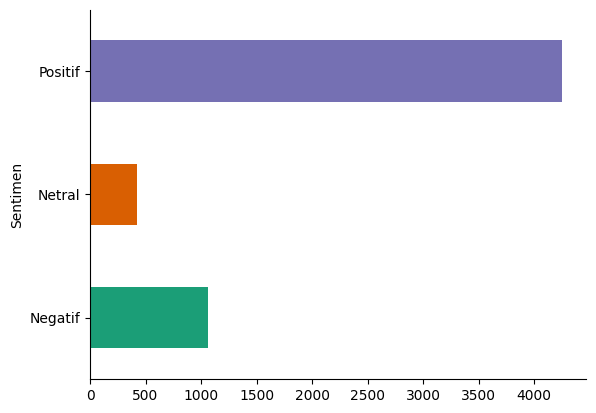

In [4]:
# @title Sentimen

from matplotlib import pyplot as plt
import seaborn as sns
data.groupby('Sentimen').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [5]:
data['Sentimen'].value_counts()

,count
Sentimen,
Positif,4254
Negatif,1062
Netral,419


## Preprocessing


In [6]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [7]:
_= !pip install nltk
_= !pip install indoNLP
_= !pip install gensim
_= !pip instal tqdm

In [15]:
import numpy as np #numpy
import re #regex
import string #string population
from nltk.tokenize import word_tokenize #tokenize
# from nltk.corpus import stopwords #stopword
from indoNLP.preprocessing import replace_slang #slank word
from nltk.stem.porter import PorterStemmer #stemming
# from tqdm.auto import tqdm #status bar
import nltk
# import os
# import warnings
# warnings.filterwarnings("ignore")

In [16]:
class Prepocessing:
      def __init__(self):
            self.listStopword =  set(stopwords.words('indonesian'))
            self.stemmer = PorterStemmer()

      def remove_emoji(self, string): #remove emoji
            emoji_pattern = re.compile("["
                  u"\U0001F600-\U0001F64F"  # emoticons
                  u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                  u"\U0001F680-\U0001F6FF"  # transport & map symbols
                  u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                  u"\U00002702-\U000027B0"
                  u"\U000024C2-\U0001F251"
                  "]+", flags=re.UNICODE)
            return emoji_pattern.sub(r' ', string)

      def remove_unwanted(self, document): #clean text
            # remove user mentions
            document = re.sub("@[A-Za-z0-9_]+"," ", document)
            # menggantdocumentkan karakter newldocumentne ("\n") dengan spasdocument
            document = re.sub("\n", " ", document)
            # menghdocumentlangkan URL yang ddocumentmuladocument dengan 'http' atau 'https' dan 'www'
            document = re.sub(r'http\S+|www\.\s+', ' ', document)
            # menghdocumentlangkan karakter non-ASCdocumentdocument dardocument teks
            document = re.sub(r'[^\x00-\x7F]+', '', document)
            # remove hashtags
            document = re.sub("#[A-Za-z0-9_]+","", document)
            # remove emojdocument's
            document = self.remove_emoji(document)
            # remove punctuatdocumenton
            document = re.sub("[^0-9A-Za-z ]", " " , document)
            # remove double spaces
            document = document.replace('  '," ")
            # menghdocumentlangkan ddocumentgdocumentt/angka dardocument teks
            document = re.sub("\d+", "", document)
            # memecah teks menjaddocument daftar kata (ldocumentst of words)
            document = document.split()
            # menggabungkan kembaldocument daftar kata menjaddocument teks dengan spasdocument sebagadocument pemdocumentsah
            document = " ".join(document)
            #hapus tab, new ldocumentne
            document = document.replace("\\t", " ").replace ("\\n", " ").replace ("\\u", " ").replace ("\\", "")
            #hapus non ASCdocumentdocument (emote, bahasa cdocumentna dll)
            document = document.encode("ascii", "replace").decode("ascii")
            # documents.append(i)
            return document

      def tokenize(self, text): #tokenize -> memisah kalimat
            return word_tokenize(str(text.translate(str.maketrans('', '', string.punctuation)).lower()))

      def normalize(self, text): #slank word -> mengganti kata yang tidak baku
            return [replace_slang(kata) for kata in text]

In [17]:
preprocessing = Prepocessing()

In [19]:
data['clean'] = data['komentar'].apply([lambda x: preprocessing.remove_unwanted(x)])

In [20]:
data['tokenize'] = data['clean'].apply(lambda x: preprocessing.tokenize(x))

In [21]:
# data.head(20)

In [22]:
# data['clean'] = data['tokenize'].apply(lambda x: preprocessing.remove_unwanted(x))
# data['clean'] = data['komentar'].apply([lambda x: preprocessing.remove_unwanted(x)])

In [23]:
data

,lokasi,Sentimen,komentar,clean,tokenize
0,Air terjun toroan,Positif,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"[air, terjun, yang, bagus, tiket, masuk, murah..."
1,Air terjun toroan,Positif,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"[tempatnya, bagus, selain, air, terjun, diatas..."
2,Air terjun toroan,Positif,Bagus,Bagus,[bagus]
3,Air terjun toroan,Positif,Mantap,Mantap,[mantap]
4,Air terjun toroan,Negatif,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"[pemandangan, yg, indah, adem, pula, suasanyan..."
...,...,...,...,...,...
5730,toron simalem,Positif,Bagus,Bagus,[bagus]
5731,toron simalem,Positif,Siiiip,Siiiip,[siiiip]
5732,toron simalem,Positif,serru,serru,[serru]
5733,toron simalem,Positif,Bagus,Bagus,[bagus]


In [24]:
# data.to_csv("/content/drive/MyDrive/DRAF/DATA/preprocessing/cleaning.csv",sep=";")

In [25]:
data['normalize'] = data['tokenize'].apply(lambda x: preprocessing.normalize(x))

In [26]:
data[['komentar', 'tokenize', 'clean', 'normalize']]

,komentar,tokenize,clean,normalize
0,Air terjun yang bagus. Tiket masuk murah sekit...,"[air, terjun, yang, bagus, tiket, masuk, murah...",Air terjun yang bagus Tiket masuk murah sekita...,"[air, terjun, yang, bagus, tiket, masuk, murah..."
1,"Tempatnya bagus selain air terjun ,diatasnya j...","[tempatnya, bagus, selain, air, terjun, diatas...",Tempatnya bagus selain air terjun diatasnya jg...,"[tempatnya, bagus, selain, air, terjun, diatas..."
2,Bagus,[bagus],Bagus,[bagus]
3,Mantap,[mantap],Mantap,[mantap]
4,"Pemandangan yg indah, adem pula suasanyanya me...","[pemandangan, yg, indah, adem, pula, suasanyan...",Pemandangan yg indah adem pula suasanyanya mes...,"[pemandangan, yang, indah, adem, pula, suasany..."
...,...,...,...,...
5730,Bagus,[bagus],Bagus,[bagus]
5731,Siiiip,[siiiip],Siiiip,[siiiip]
5732,serru,[serru],serru,[serru]
5733,Bagus,[bagus],Bagus,[bagus]


In [27]:
from nltk.corpus import stopwords
nltk.download('stopwords')

# ----------------------- get stopword from NLTK stopword -------------------------------
# get stopword indonesia
list_stopwords = stopwords.words('indonesian')


# ---------------------------- manualy add stopword  ------------------------------------
# append additional stopword
list_stopwords.extend(["nya", "jg", "yg", "dg", "rt", "dgn", "ny", "d", 'klo',
                       'kalo', 'amp', 'biar', 'bikin', 'bilang',
                       'gak', 'ga', 'krn', 'nya', 'nih', 'sih',
                       'si', 'tau', 'tdk', 'tuh', 'utk', 'ya',
                       'jd', 'jgn', 'sdh', 'aja', 'n', 't',
                       'nyg', 'hehe', 'pen', 'u', 'nan', 'loh', 'rt',
                       '&amp', 'yah'])

# ----------------------- add stopword from txt file ------------------------------------
# read txt stopword using pandas
txt_stopword = pd.read_csv("https://raw.githubusercontent.com/masdevid/ID-Stopwords/master/id.stopwords.02.01.2016.txt", names= ["stopwords"], header = None)

# convert stopword string to list & append additional stopword
list_stopwords.extend(txt_stopword["stopwords"][0].split(' '))

# ---------------------------------------------------------------------------------------

# convert list to dictionary
list_stopwords = set(list_stopwords)


#remove stopword pada list token
def stopwords_removal(words):
    return [word for word in words if word not in list_stopwords]

data['stopword'] = data['normalize'].apply(stopwords_removal)
data[["stopword"]]

# print(dataps['stopword'].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,stopword
0,"[air, terjun, bagus, tiket, masuk, murah, ribu..."
1,"[tempatnya, bagus, air, terjun, diatasnya, res..."
2,[bagus]
3,[mantap]
4,"[pemandangan, indah, adem, suasanyanya, pinggi..."
...,...
5730,[bagus]
5731,[siiiip]
5732,[serru]
5733,[bagus]


In [28]:
_= !pip install swifter
_= !pip install Sastrawi

In [29]:
# import Sastrawi package
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import swifter


# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# stemmed
def stemmed_wrapper(term):
    return stemmer.stem(term)

term_dict = {}

for document in data['stopword']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

# print(len(term_dict))
# print("------------------------")

for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    print(term,":" ,term_dict[term])

# print(term_dict)
# print("------------------------")


# apply stemmed term to dataframe
def get_stemmed_term(document):
    return [term_dict[term] for term in document]

data['stemming'] = data['stopword'].swifter.apply(get_stemmed_term)


Output streaming akan dipotong hingga 5000 baris terakhir.
pesona : pesona
indahnya : indah
pemerintahan : perintah
pembangunan : bangun
kawasan : kawasan
gencar : gencar
disepanjang : panjang
bibir : bibir
terletak : letak
tenggelam : tenggelam
medannya : medan
lancar : lancar
diperbolehkan : boleh
menelan : tel
korban : korban
jiwa : jiwa
kemah : kemah
kalender : kalender
mah : mah
diterusin : diterusin
takut : takut
keseret : seret
worth : worth
tenang : tenang
kristal : kristal
parkirannya : parkir
panas : panas
teduh : teduh
jalanan : jalan
man : man
teman : teman
kct : kct
kbt : kbt
kunjungi : kunjung
all : all
turns : turns
sejagat : jagat
best : best
samudera : samudera
nayaman : nayam
merusak : rusak
berhulu : hulu
pemukiman : mukim
pantura : pantura
bangkalan : bangkal
kamar : kamar
mushola : mushola
pemandang : pandang
coba : coba
tengok : tengok
keatas : atas
ditinggalkan : tinggal
pengunjung : unjung
istimewa : istimewa
memandang : pandang
saty : saty
rumah : rumah
pelangg

Pandas Apply:   0%|          | 0/5735 [00:00<?, ?it/s]

In [30]:
data[['stemming']]

,stemming
0,"[air, terjun, bagus, tiket, masuk, murah, ribu..."
1,"[tempat, bagus, air, terjun, atas, rest, area,..."
2,[bagus]
3,[mantap]
4,"[pandang, indah, adem, suasanyanya, pinggir, l..."
...,...
5730,[bagus]
5731,[siiiip]
5732,[serru]
5733,[bagus]


In [31]:
data=data.reset_index(drop=True)

In [32]:
data

,lokasi,Sentimen,komentar,clean,tokenize,normalize,stopword,stemming
0,Air terjun toroan,Positif,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"[air, terjun, yang, bagus, tiket, masuk, murah...","[air, terjun, yang, bagus, tiket, masuk, murah...","[air, terjun, bagus, tiket, masuk, murah, ribu...","[air, terjun, bagus, tiket, masuk, murah, ribu..."
1,Air terjun toroan,Positif,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"[tempatnya, bagus, selain, air, terjun, diatas...","[tempatnya, bagus, selain, air, terjun, diatas...","[tempatnya, bagus, air, terjun, diatasnya, res...","[tempat, bagus, air, terjun, atas, rest, area,..."
2,Air terjun toroan,Positif,Bagus,Bagus,[bagus],[bagus],[bagus],[bagus]
3,Air terjun toroan,Positif,Mantap,Mantap,[mantap],[mantap],[mantap],[mantap]
4,Air terjun toroan,Negatif,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"[pemandangan, yg, indah, adem, pula, suasanyan...","[pemandangan, yang, indah, adem, pula, suasany...","[pemandangan, indah, adem, suasanyanya, pinggi...","[pandang, indah, adem, suasanyanya, pinggir, l..."
...,...,...,...,...,...,...,...,...
5730,toron simalem,Positif,Bagus,Bagus,[bagus],[bagus],[bagus],[bagus]
5731,toron simalem,Positif,Siiiip,Siiiip,[siiiip],[siiiip],[siiiip],[siiiip]
5732,toron simalem,Positif,serru,serru,[serru],[serru],[serru],[serru]
5733,toron simalem,Positif,Bagus,Bagus,[bagus],[bagus],[bagus],[bagus]


In [33]:
# data.to_csv("/content/drive/MyDrive/Textmining/metode/DATA/PREPROCESSING/prepro_mentah.csv",sep=";")

# stop

In [34]:
# menghilangkan data yang kosong
for i in range(len(data['stemming'])):
  if data['stemming'][i]==[]:
    print(i, data['stemming'][i])
    data.drop(i , inplace=True)

237 []
252 []
492 []
500 []
682 []
706 []
711 []
868 []
870 []
877 []
881 []
991 []
994 []
997 []
1009 []
1063 []
1077 []
1125 []
1139 []
1144 []
1145 []
1147 []
1910 []
2360 []
2415 []
2472 []
2600 []
2602 []
2698 []
2828 []
2875 []
2882 []
2899 []
3127 []
3158 []
3178 []
3304 []
3337 []
3338 []
3366 []
3426 []
3443 []
3459 []
3710 []
3738 []
3760 []
3796 []
3808 []
3814 []
3964 []
3986 []
4000 []
4052 []
4068 []
4073 []
4074 []
4131 []
4179 []
4192 []
4536 []
4855 []
5006 []
5014 []
5021 []
5092 []
5160 []
5169 []
5177 []
5193 []
5387 []
5391 []
5463 []
5471 []
5474 []
5500 []
5548 []
5560 []
5644 []
5659 []
5682 []
5683 []
5687 []
5713 []
5715 []
5723 []
5724 []
5728 []


In [35]:
data = data.reset_index()

In [36]:
data

,index,lokasi,Sentimen,komentar,clean,tokenize,normalize,stopword,stemming
0,0,Air terjun toroan,Positif,Air terjun yang bagus. Tiket masuk murah sekit...,Air terjun yang bagus Tiket masuk murah sekita...,"[air, terjun, yang, bagus, tiket, masuk, murah...","[air, terjun, yang, bagus, tiket, masuk, murah...","[air, terjun, bagus, tiket, masuk, murah, ribu...","[air, terjun, bagus, tiket, masuk, murah, ribu..."
1,1,Air terjun toroan,Positif,"Tempatnya bagus selain air terjun ,diatasnya j...",Tempatnya bagus selain air terjun diatasnya jg...,"[tempatnya, bagus, selain, air, terjun, diatas...","[tempatnya, bagus, selain, air, terjun, diatas...","[tempatnya, bagus, air, terjun, diatasnya, res...","[tempat, bagus, air, terjun, atas, rest, area,..."
2,2,Air terjun toroan,Positif,Bagus,Bagus,[bagus],[bagus],[bagus],[bagus]
3,3,Air terjun toroan,Positif,Mantap,Mantap,[mantap],[mantap],[mantap],[mantap]
4,4,Air terjun toroan,Negatif,"Pemandangan yg indah, adem pula suasanyanya me...",Pemandangan yg indah adem pula suasanyanya mes...,"[pemandangan, yg, indah, adem, pula, suasanyan...","[pemandangan, yang, indah, adem, pula, suasany...","[pemandangan, indah, adem, suasanyanya, pinggi...","[pandang, indah, adem, suasanyanya, pinggir, l..."
...,...,...,...,...,...,...,...,...,...
5643,5730,toron simalem,Positif,Bagus,Bagus,[bagus],[bagus],[bagus],[bagus]
5644,5731,toron simalem,Positif,Siiiip,Siiiip,[siiiip],[siiiip],[siiiip],[siiiip]
5645,5732,toron simalem,Positif,serru,serru,[serru],[serru],[serru],[serru]
5646,5733,toron simalem,Positif,Bagus,Bagus,[bagus],[bagus],[bagus],[bagus]


In [37]:
# data.to_csv("/content/drive/MyDrive/Textmining/metode/DATA/PREPROCESSING/preprofix.csv",sep=";")

In [38]:
# data["stemming"].to_csv("/content/drive/MyDrive/Textmining/metode/DATA/PREPROCESSING/stemming.csv",sep=";")